# GANisme — 09. Passage en 128×160 (portraits)

**Pourquoi.** Le modèle final en 64×80 (notebook 08) produit des portraits bien construits, mais **les visages restent
souvent déformés** : à cette résolution, un visage occupe une quinzaine de pixels. Doubler la résolution est le levier
le plus direct.

**Ce qui change.** Le générateur reçoit une couche de doublement supplémentaire, le discriminateur une couche de
réduction supplémentaire (5 au lieu de 4, toujours à partir d'une grille 5×4). Il y a deux façons d'ajouter cette
couche ; on teste les deux :

| | Filtres du générateur, de la grille 5×4 à l'image | Paramètres de G |
|---|---|---|
| Modèle 64×80 (référence) | 512 → 256 → 128 → 64 → image | 3,8 M |
| **128×160, largeur 64** | 1 024 → 512 → 256 → 128 → 64 → image | 13,2 M |
| **128×160, largeur 32** | 512 → 256 → 128 → 64 → 32 → image | 3,8 M |

**Ce qui ne change pas.** Les hyperparamètres du modèle final 64×80 (réglage Optuna n°26), les données (mêmes 3 448
portraits, stockés dès le départ en 128×160), la graine (42), 600 époques, le protocole d'évaluation.

| | |
|---|---|
| Code | `src/run_portrait_128.py` (file d'entraînements reprenable), option `--resume` de `src/train.py` |
| Commande | `python src/run_portrait_128.py` |

**Une difficulté de lecture.** Les scores en 128×160 ne se comparent pas à ceux en 64×80 : l'échelle de référence
change avec la résolution (notebook 03). On mesure donc chaque modèle **deux fois** : à sa résolution d'origine,
contre les références en 128×160 ; puis **réduit en 64×80**, contre exactement la même référence que le modèle final.

**Limite annoncée** : un seul entraînement par architecture.

In [1]:
import json
import shutil
import sys
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import torch
from PIL import Image
from matplotlib_inline.backend_inline import set_matplotlib_formats

warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
import dataset as ds          # noqa: E402
import generate as gn         # noqa: E402
import metrics as mt          # noqa: E402
import train as tr            # noqa: E402
from models import Discriminator, Generator, base_grid, count_params   # noqa: E402

FIG_DIR = ROOT / "reports" / "figures"
RUNS = ROOT / "runs"
BIG, SMALL = (128, 160), (64, 80)
FINAL_64 = "optuna26_portrait_64_s1"
set_matplotlib_formats("jpeg", pil_kwargs={"quality": 88})

CAT = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
MAIN, OTHER = CAT[0], "#c3c2b7"
INK, INK2, MUTED, GRID, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#fcfcfb"
plt.rcParams.update({
    "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
    "font.family": "sans-serif", "font.sans-serif": ["Segoe UI", "DejaVu Sans", "Arial"],
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold", "axes.titlelocation": "left",
    "axes.titlecolor": INK, "axes.labelcolor": INK2, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": INK2, "axes.edgecolor": OTHER,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.axisbelow": True,
    "legend.frameon": False, "lines.linewidth": 2,
})


def save(fig, name):
    fig.savefig(FIG_DIR / f"p128_{name}.png")


MODELS = {"portrait_128_w64_s42": ("128×160, largeur 64", CAT[0]), "portrait_128_w32_s42": ("128×160, largeur 32", CAT[1])}
runs = {n: {"cfg": json.loads((RUNS / n / "config.json").read_text(encoding="utf-8")),
            "eval": pd.read_csv(RUNS / n / "eval.csv"), "hist": pd.read_csv(RUNS / n / "history.csv")} for n in MODELS}
baselines = pd.read_csv(ROOT / "reports" / "metrics" / "baselines.csv")
bl = {r: baselines[(baselines["genre"] == "portrait") & (baselines["résolution"] == r)].set_index("baseline") for r in ("128×160", "64×80")}
for n, r in runs.items():
    print(f"{MODELS[n][0]} : {len(r['eval'])} évaluations, {r['hist']['seconds'].mean():.1f} s par époque, "
          f"{r['eval']['train_minutes'].iloc[-1]:.0f} min au total")

128×160, largeur 64 : 25 évaluations, 13.8 s par époque, 152 min au total
128×160, largeur 32 : 25 évaluations, 5.6 s par époque, 70 min au total


## 1. Les deux architectures

In [2]:
def layer_table(model, x):
    rows = []
    for layer in model.net:
        x = layer(x)
        n = sum(p.numel() for p in layer.parameters())
        if n:
            rows.append({"couche": layer.__class__.__name__.replace("Parametrized", ""), "sortie (canaux × h × l)": " × ".join(map(str, x.shape[1:])),
                         "paramètres": f"{n:,}".replace(",", " ")})
    return pd.DataFrame(rows)


for n, r in runs.items():
    c = r["cfg"]
    base = base_grid(tuple(c["size"]), c["n_up"])
    G = Generator(c["nz"], c["ngf"], base, c["n_up"]); D = Discriminator(c["ndf"], base, c["n_up"], spectral=c["spectral_norm"])
    with torch.no_grad():
        tg = layer_table(G, torch.randn(2, c["nz"], 1, 1))
    print(f"{MODELS[n][0]} — G : {count_params(G):,} paramètres | D : {count_params(D):,} paramètres".replace(",", " "))
    display(tg.style.set_caption(f"Générateur — {MODELS[n][0]}"))

128×160  largeur 64 — G : 13 196 160 paramètres | D : 11 166 657 paramètres


,couche,sortie (canaux × h × l),paramètres
0,ConvTranspose2d,1024 × 5 × 4,2 048 000
1,BatchNorm2d,1024 × 5 × 4,2 048
2,ConvTranspose2d,512 × 10 × 8,8 388 608
3,BatchNorm2d,512 × 10 × 8,1 024
4,ConvTranspose2d,256 × 20 × 16,2 097 152
5,BatchNorm2d,256 × 20 × 16,512
6,ConvTranspose2d,128 × 40 × 32,524 288
7,BatchNorm2d,128 × 40 × 32,256
8,ConvTranspose2d,64 × 80 × 64,131 072
9,BatchNorm2d,64 × 80 × 64,128


128×160  largeur 32 — G : 3 812 800 paramètres | D : 2 798 049 paramètres


,couche,sortie (canaux × h × l),paramètres
0,ConvTranspose2d,512 × 5 × 4,1 024 000
1,BatchNorm2d,512 × 5 × 4,1 024
2,ConvTranspose2d,256 × 10 × 8,2 097 152
3,BatchNorm2d,256 × 10 × 8,512
4,ConvTranspose2d,128 × 20 × 16,524 288
5,BatchNorm2d,128 × 20 × 16,256
6,ConvTranspose2d,64 × 40 × 32,131 072
7,BatchNorm2d,64 × 40 × 32,128
8,ConvTranspose2d,32 × 80 × 64,32 768
9,BatchNorm2d,32 × 80 × 64,64


**Lecture** — les deux réseaux ont la même profondeur (5 couches de doublement) ; seule la largeur change. En largeur
64, la première couche du générateur porte 1 024 filtres et concentre l'essentiel des 13,2 millions de paramètres.
En largeur 32, le générateur est celui du modèle 64×80, prolongé d'une couche de 32 filtres : même nombre de
paramètres (3,8 millions).

**Coût mesuré** : 13,8 s par époque en largeur 64 (2 h 32 pour 600 époques), 5,6 s en largeur 32 (1 h 10), contre 2,9 s
pour le modèle 64×80 (42 minutes).

## 2. Courbes d'apprentissage

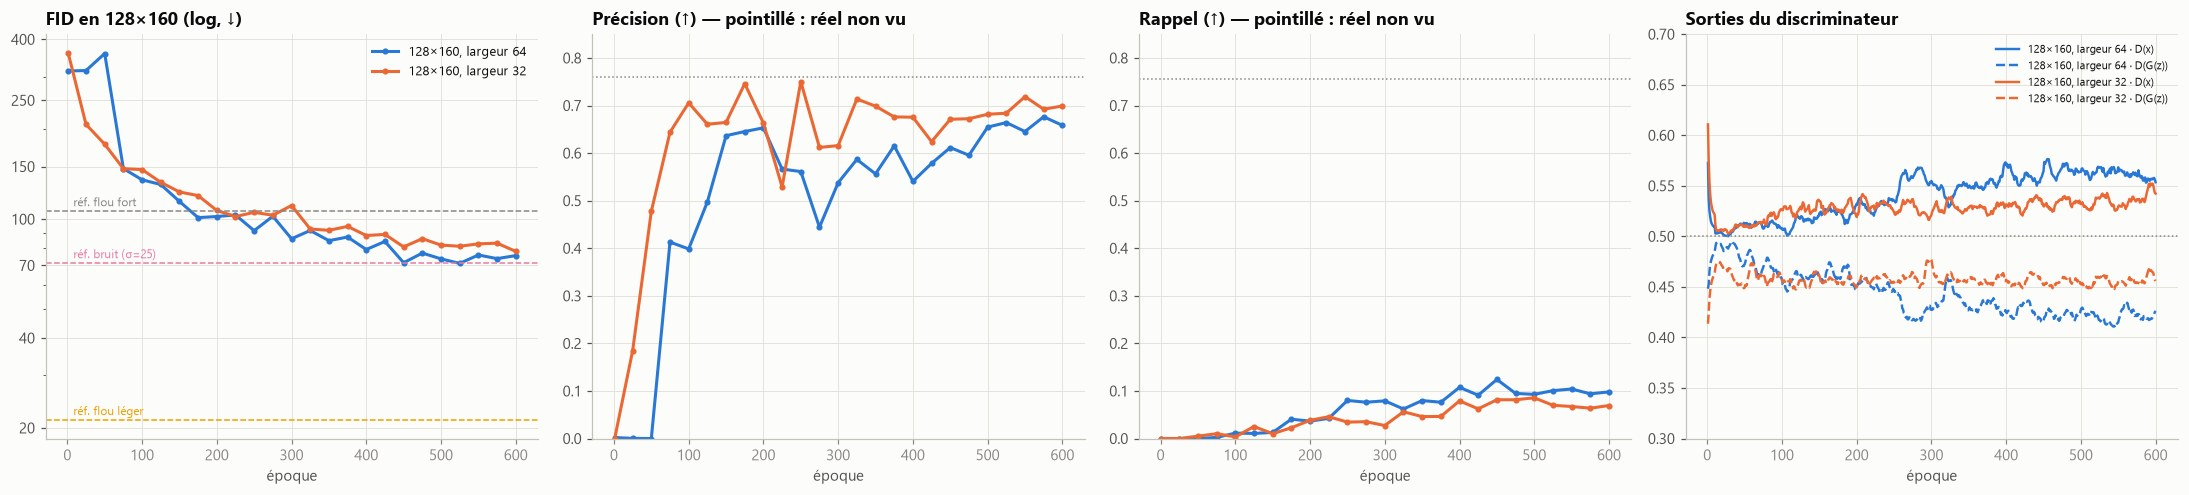

128×160, largeur 64 : meilleur FID 71.1 à l'époque 525 ; époque 600 : 75.5 ; étendue sur les époques 450 à 600 : 71.1 à 77.0
128×160, largeur 32 : meilleur FID 78.0 à l'époque 600 ; époque 600 : 78.0 ; étendue sur les époques 450 à 600 : 78.0 à 86.0


In [3]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.6))
for n, r in runs.items():
    e, h, (lbl, col) = r["eval"], r["hist"], MODELS[n]
    axes[0].plot(e["epoch"], e["FID"], color=col, marker="o", ms=3, label=lbl)
    axes[1].plot(e["epoch"], e["precision"], color=col, marker="o", ms=3, label=lbl)
    axes[2].plot(e["epoch"], e["recall"], color=col, marker="o", ms=3, label=lbl)
    axes[3].plot(h["epoch"], h["d_real"].rolling(10, min_periods=1).mean(), color=col, lw=1.6, label=f"{lbl} · D(x)")
    axes[3].plot(h["epoch"], h["d_fake"].rolling(10, min_periods=1).mean(), color=col, lw=1.6, ls="--", label=f"{lbl} · D(G(z))")
for lbl, c in [("Flou léger", CAT[3]), ("Bruit (σ=25)", CAT[4]), ("Flou fort", MUTED)]:
    axes[0].axhline(bl["128×160"].loc[lbl, "FID"], color=c, ls="--", lw=1)
    axes[0].text(8, bl["128×160"].loc[lbl, "FID"] * 1.04, f"réf. {lbl.lower()}", ha="left", fontsize=8, color=c)
axes[0].set_yscale("log"); axes[0].set_yticks([20, 40, 70, 100, 150, 250, 400])
axes[0].yaxis.set_major_formatter(mtick.ScalarFormatter()); axes[0].yaxis.set_minor_formatter(mtick.NullFormatter())
axes[0].set_title("FID en 128×160 (log, ↓)"); axes[0].legend(loc="upper right", fontsize=8.5)
for ax, key, title in [(axes[1], "precision", "Précision (↑)"), (axes[2], "recall", "Rappel (↑)")]:
    ax.axhline(bl["128×160"].loc["Réel non vu (test)", key], color=MUTED, ls=":", lw=1)
    ax.set_ylim(0, 0.85); ax.set_title(title + " — pointillé : réel non vu")
axes[3].axhline(0.5, color=MUTED, ls=":", lw=1); axes[3].set_ylim(0.3, 0.7)
axes[3].set_title("Sorties du discriminateur"); axes[3].legend(fontsize=7.5)
for ax in axes:
    ax.set_xlabel("époque")
plt.tight_layout()
save(fig, "01_curves")
plt.show()

for n, r in runs.items():
    e = r["eval"]; b = e.loc[e["FID"].idxmin()]
    late = e[e["epoch"] >= 450]["FID"]
    print(f"{MODELS[n][0]} : meilleur FID {b['FID']:.1f} à l'époque {int(b['epoch'])} ; époque 600 : {e['FID'].iloc[-1]:.1f} ; "
          f"étendue sur les époques 450 à 600 : {late.min():.1f} à {late.max():.1f}")

**Observations**

- **Les deux entraînements sont stables**, sans aucune crise. Le discriminateur reste proche de l'équilibre du début à
  la fin (0,55 pour le vrai et 0,44 pour le faux en largeur 64 ; 0,53 et 0,46 en largeur 32). Les hyperparamètres
  réglés en 64×80 se transposent donc à la résolution supérieure, ce qui n'était pas acquis.
- **Le démarrage est plus lent qu'en 64×80** : le modèle de largeur 64 reste bloqué au-dessus de 300 de FID pendant
  les 50 premières époques, avant de décrocher brutalement.
- **La largeur 64 prend l'avantage à partir de l'époque 250** et le garde.
- **Les deux modèles ne sont pas au même stade** : la largeur 64 oscille entre 71 et 77 depuis l'époque 450 (plateau),
  alors que la largeur 32 obtient son meilleur score à la toute dernière époque (78,0) — elle progressait encore.
- Comme en 64×80, **la précision monte vite et le rappel lentement**.

## 3. Scores à la résolution d'origine (128×160)

Meilleur checkpoint de chaque modèle, face aux « faux générateurs » de référence calculés en 128×160 (notebook 03).

In [4]:
cols = ["FID", "FID_ntest", "KID_x1000", "precision", "recall", "density", "coverage", "mem_ratio", "copies"]
native = pd.DataFrame({MODELS[n][0] + f" (époque {int(r['eval'].loc[r['eval']['FID'].idxmin(), 'epoch'])})":
                       r["eval"].loc[r["eval"]["FID"].idxmin(), cols] for n, r in runs.items()}).T
refs = bl["128×160"].loc[["Réel non vu (test)", "Flou léger", "Bruit (σ=25)", "Flou fort", "Mode collapse (20 images)"], cols]
refs.index = "réf. · " + refs.index
pd.concat([native, refs]).astype(float).round(3)

,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
"128×160, largeur 64 (époque 525)",71.095,112.853,52.013,0.664,0.101,0.668,0.408,1.071,0.000
"128×160, largeur 32 (époque 600)",77.991,120.122,61.757,0.699,0.069,0.688,0.375,1.083,0.000
réf. · Réel non vu (test),60.819,60.819,-0.279,0.760,0.756,1.059,0.427,1.000,0.010
réf. · Flou léger,21.230,70.660,11.047,0.993,0.992,0.725,0.997,0.748,0.447
réf. · Bruit (σ=25),71.116,119.533,68.657,0.423,0.547,0.144,0.431,1.087,0.010
réf. · Flou fort,106.176,154.475,84.662,0.142,0.198,0.040,0.114,1.191,0.002
réf. · Mode collapse (20 images),209.227,209.738,15.903,1.000,0.005,0.801,0.024,0.001,1.000


**Observations**

- La largeur 64 obtient un **FID de 71,1**, la largeur 32 de 78,0. Sur l'échelle de référence en 128×160, les deux se
  situent au niveau « bruit » (71) : mieux que le « flou fort » (106), loin du « flou léger » (21).
- **La précision est bonne (0,66 et 0,70, pour 0,76 côté réel)** : les images produites ressemblent à des portraits.
- **Le rappel est faible (0,10 et 0,07, pour 0,76 côté réel)** : à cette résolution, le générateur couvre mal la
  variété des détails fins des vraies peintures. C'est le point faible principal.
- **Aucune mémorisation** : `mem_ratio` de 1,07 et 1,08, 0 % de copies. Passer à 13 millions de paramètres avec
  3 448 images faisait craindre un sur-apprentissage ; il n'a pas eu lieu.

## 4. Comparaison équitable avec le modèle 64×80

Les 3 448 images de chaque modèle 128×160 sont **réduites en 64×80** avec le même filtre (Lanczos) que celui qui a
servi à fabriquer le jeu de données 64×80, puis évaluées contre la même référence que le modèle final. Les écarts ne
peuvent donc venir que des modèles.

In [5]:
ref64 = mt.Reference.load_or_compute("portrait", SMALL, ds.DATASETS / "portrait")
rows, G128 = {}, {}
for n in MODELS:
    G, info = gn.load_generator(n, "best")
    G128[n] = G
    z = tr.evaluation_latents(len(ref64.train), G.nz, next(G.parameters()).device, seed=42)
    big = tr.generate(G, z, batch_size=128).permute(0, 2, 3, 1).cpu().numpy()
    small = np.stack([np.asarray(Image.fromarray(x).resize(SMALL, Image.LANCZOS)) for x in big])
    f, lg = mt.extract_features(small)
    rows[MODELS[n][0] + ", réduit en 64×80"] = pd.Series(mt.evaluate(f, lg, ref64))[cols]
_, i64 = gn.load_generator(FINAL_64, "best")
rows["Modèle final 64×80 (meilleure graine)"] = pd.Series(i64["scores"])[cols]
summ = pd.read_csv(ROOT / "reports" / "metrics" / "summary_portrait_64.csv", index_col=0)
rows["Réglage 64×80, moyenne de 3 graines"] = summ.loc[[i for i in summ.index if "n°26" in i][0], cols]
refs = bl["64×80"].loc[["Réel non vu (test)", "Flou léger"], cols]; refs.index = "réf. · " + refs.index
fair = pd.concat([pd.DataFrame(rows).T, refs]).astype(float)
fair.to_csv(ROOT / "reports" / "metrics" / "portrait_128_vs_64.csv")
fair.round(3)

,FID,FID_ntest,KID_x1000,precision,recall,density,coverage,mem_ratio,copies
"128×160, largeur 64, réduit en 64×80",41.127,83.691,23.266,0.672,0.302,0.708,0.644,1.072,0.001
"128×160, largeur 32, réduit en 64×80",45.312,88.779,30.242,0.696,0.276,0.791,0.630,1.088,0.000
Modèle final 64×80 (meilleure graine),54.496,97.549,37.325,0.624,0.278,0.610,0.536,1.108,0.000
"Réglage 64×80, moyenne de 3 graines",55.352,99.089,37.946,0.619,0.265,0.574,0.499,1.110,0.000
réf. · Réel non vu (test),57.562,57.562,-0.223,0.776,0.785,0.913,0.396,1.000,0.010
réf. · Flou léger,61.232,106.555,56.554,0.684,0.712,0.268,0.671,1.025,0.029


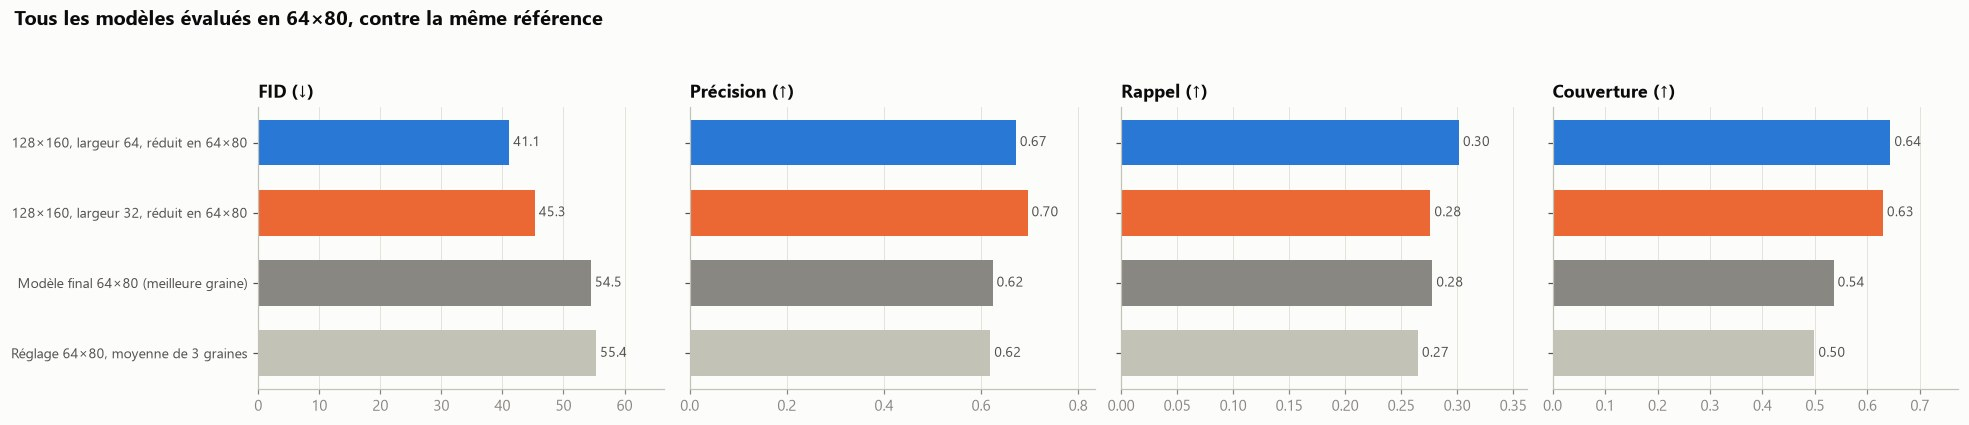

In [6]:
names = list(rows)
fig, axes = plt.subplots(1, 4, figsize=(18, 3.9))
colors = [CAT[0], CAT[1], MUTED, OTHER]
for ax, key, title in zip(axes, ["FID", "precision", "recall", "coverage"],
                          ["FID (↓)", "Précision (↑)", "Rappel (↑)", "Couverture (↑)"]):
    vals = fair.loc[names, key]
    ax.barh(range(len(names)), vals, color=colors, height=0.65)
    for i, v in enumerate(vals):
        ax.text(v, i, f" {v:.1f}" if key == "FID" else f" {v:.2f}", va="center", fontsize=9, color=INK2)
    ax.set_yticks(range(len(names)), names if ax is axes[0] else [""] * len(names), fontsize=9); ax.invert_yaxis()
    ax.set_xlim(0, vals.max() * 1.2); ax.set_title(title); ax.grid(axis="y", visible=False)
fig.suptitle("Tous les modèles évalués en 64×80, contre la même référence", x=0.01, ha="left", fontsize=13, fontweight="bold")
plt.tight_layout(rect=(0, 0, 1, 0.93))
save(fig, "02_fair_comparison")
plt.show()

**Observations — le résultat principal du notebook**

- **Réduits en 64×80, les deux modèles 128×160 battent le modèle final 64×80** : FID de **41,1** (largeur 64) et 45,3
  (largeur 32), contre 54,5. Précision, densité et couverture progressent aussi ; le rappel reste au même niveau.
- **L'écart dépasse largement le hasard** : 13 points de FID, alors que les trois graines du réglage 64×80 ne
  s'écartent que de 0,75 point entre elles (meilleurs checkpoints). Apprendre à dessiner en haute résolution améliore
  aussi la structure d'ensemble de l'image.
- **Entre les deux largeurs, l'écart (4 points) est moins sûr** : un seul entraînement chacune, et la largeur 32
  n'avait pas fini de converger.
- **Lecture croisée avec la section 3** : réduit en 64×80, le rappel de la largeur 64 est de 0,30 ; à sa résolution
  d'origine, il tombe à 0,10. La réduction moyenne les pixels et efface les détails fins : ce qui manque au modèle se
  situe donc bien dans ces détails (textures, traits du visage), pas dans la composition.

## 5. Les images

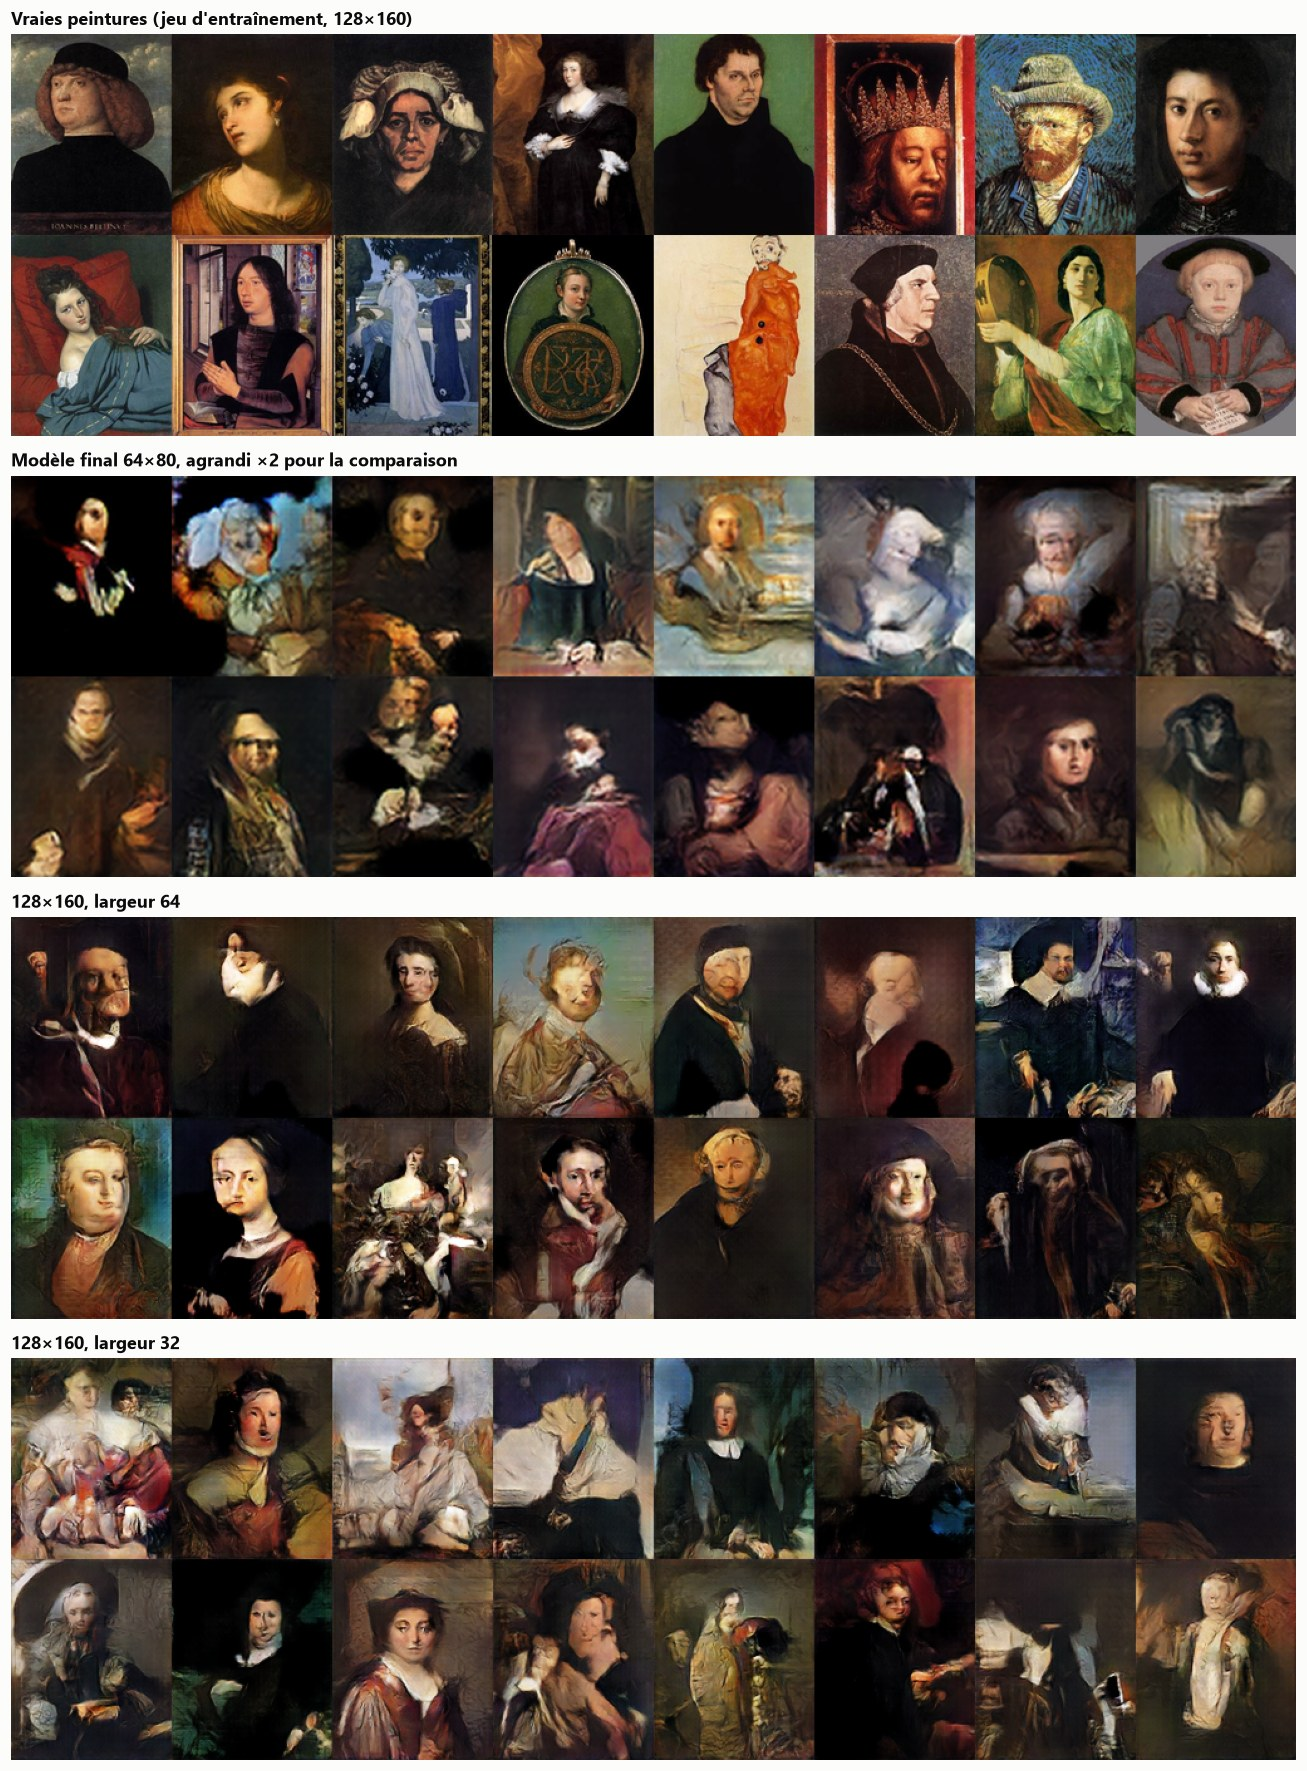

In [7]:
real = ds.load_split("portrait", "train", BIG)
real = real[np.random.default_rng(123).choice(len(real), 16, replace=False)]
mosaic = lambda imgs, ncol=8: np.concatenate([np.concatenate(list(imgs[i:i + ncol]), axis=1) for i in range(0, len(imgs), ncol)])
G64, _ = gn.load_generator(FINAL_64, "best")
up64 = np.stack([np.asarray(Image.fromarray(x).resize(BIG, Image.LANCZOS)) for x in gn.sample(G64, 16, seed=123)])
panels = [("Vraies peintures (jeu d'entraînement, 128×160)", real),
          ("Modèle final 64×80, agrandi ×2 pour la comparaison", up64)] + \
         [(MODELS[n][0], gn.sample(G128[n], 16, seed=123)) for n in MODELS]
fig, axes = plt.subplots(len(panels), 1, figsize=(15, 4.05 * len(panels)))
for ax, (title, imgs) in zip(axes, panels):
    ax.imshow(mosaic(imgs)); ax.axis("off"); ax.set_title(title)
plt.tight_layout()
save(fig, "03_samples")
plt.show()

**Observations**

- **Les visages sont nettement mieux formés** qu'en 64×80 : yeux, nez et bouche sont souvent lisibles, parfois une
  barbe ou un regard. Le modèle 64×80 agrandi ne montre que des taches à la place du visage.
- **Les vêtements et accessoires gagnent en détail** : cols blancs, fraises, drapés, chapeaux.
- **Il reste des ratés** : visages asymétriques ou fondus, mains difformes, quelques images sans sujet reconnaissable.
- **La largeur 32** donne des portraits de qualité voisine, un peu plus souvent déformés.
- Comparées aux vraies peintures, les images générées manquent encore de **netteté dans les textures** : c'est ce que
  mesure le rappel faible de la section 3.

## 6. Modèle retenu en 128×160

Règle fixée avant de regarder les images : le modèle dont le **FID réduit en 64×80** est le plus bas — c'est la mesure
directement comparable au modèle actuel. Ses poids sont copiés dans `models/portrait_128.pt`.

Modèle retenu : portrait_128_w64_s42 (128×160, largeur 64) -> models/portrait_128.pt


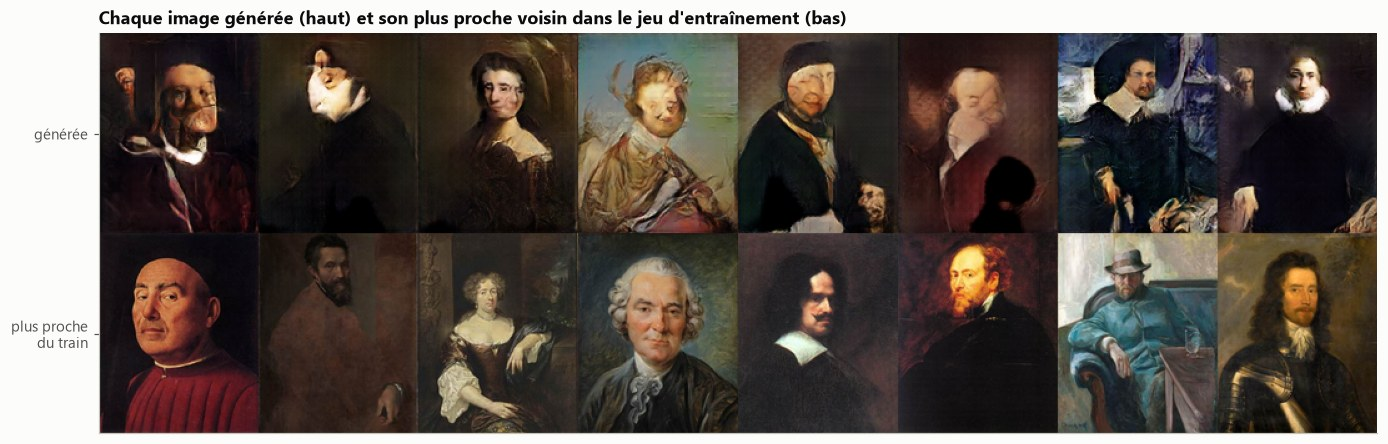

In [8]:
best_name = min(MODELS, key=lambda n: fair.loc[MODELS[n][0] + ", réduit en 64×80", "FID"])
(ROOT / "models").mkdir(exist_ok=True)
shutil.copy2(RUNS / best_name / "checkpoints" / "best.pt", ROOT / "models" / "portrait_128.pt")
G = G128[best_name]
print(f"Modèle retenu : {best_name} ({MODELS[best_name][0]}) -> models/portrait_128.pt")

# Memorisation: nearest neighbour in the training set
ref128 = mt.Reference.load_or_compute("portrait", BIG, ds.DATASETS / "portrait")
train_all = ds.load_split("portrait", "train", BIG)
fake = gn.sample(G, 8, seed=123)
f_fake, _ = mt.extract_features(fake)
nn_idx = torch.cdist(torch.from_numpy(f_fake).float(), torch.from_numpy(ref128.train).float()).argmin(1).numpy()
fig, ax = plt.subplots(figsize=(15, 5))
ax.imshow(np.concatenate([np.concatenate(list(fake), axis=1), np.concatenate([train_all[i] for i in nn_idx], axis=1)]))
ax.set_xticks([]); ax.set_yticks([BIG[1] / 2, BIG[1] * 1.5], ["générée", "plus proche\ndu train"]); ax.grid(False)
ax.set_title("Chaque image générée (haut) et son plus proche voisin dans le jeu d'entraînement (bas)")
save(fig, "04_nearest_neighbors")
plt.show()

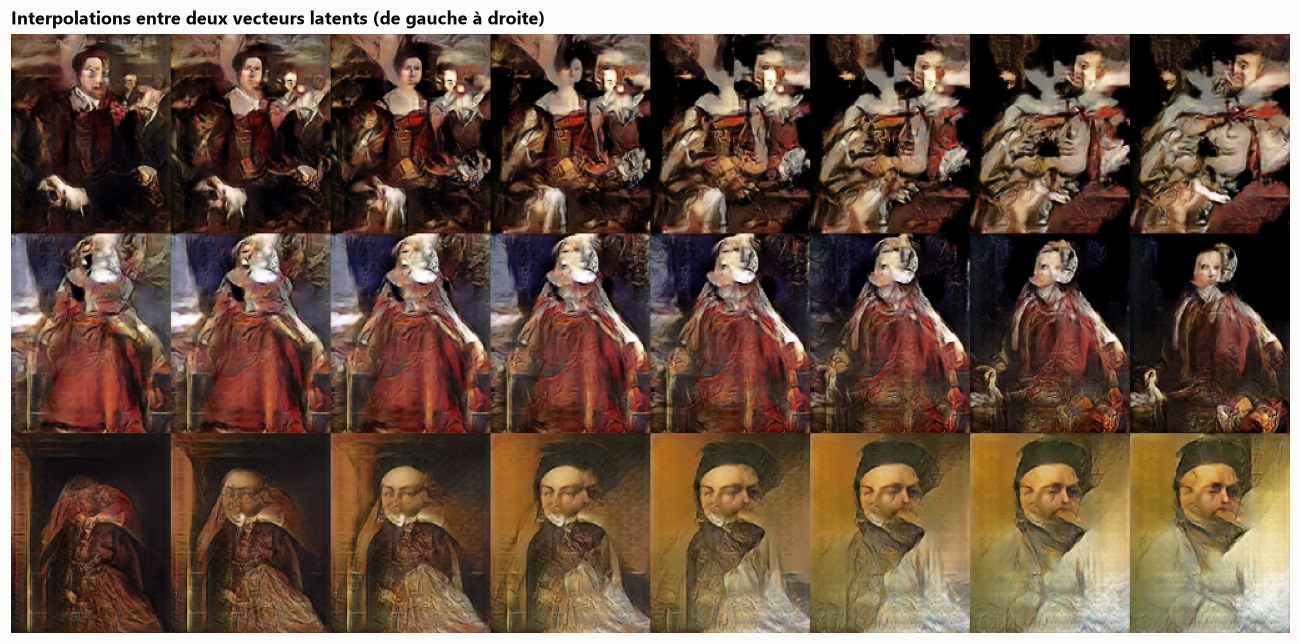

In [9]:
def slerp(a, b, t):
    omega = torch.acos((a / a.norm() * b / b.norm()).sum().clamp(-1, 1))
    return (torch.sin((1 - t) * omega) * a + torch.sin(t * omega) * b) / torch.sin(omega)


dev = next(G.parameters()).device
g = torch.Generator().manual_seed(7)
strips = []
with torch.no_grad():
    for _ in range(3):
        a, b = torch.randn(G.nz, generator=g), torch.randn(G.nz, generator=g)
        z = torch.stack([slerp(a, b, t) for t in torch.linspace(0, 1, 8)]).to(dev)
        x = G(z).clamp(-1, 1).add(1).mul(127.5).round().to(torch.uint8).permute(0, 2, 3, 1).cpu().numpy()
        strips.append(np.concatenate(list(x), axis=1))
fig, ax = plt.subplots(figsize=(15, 8.6))
ax.imshow(np.concatenate(strips)); ax.axis("off")
ax.set_title("Interpolations entre deux vecteurs latents (de gauche à droite)")
save(fig, "05_interpolation")
plt.show()

**Observations**

- **Modèle retenu : largeur 64**, meilleur checkpoint à l'époque 525. Poids : `models/portrait_128.pt`.
- **Pas de copie** : les plus proches voisins dans le jeu d'entraînement sont d'autres œuvres ; ils partagent la
  palette et la pose, pas le sujet.
- **Interpolations continues** : un personnage se transforme progressivement en un autre, sans saut.

## 7. Conclusion

| | Modèle final 64×80 | 128×160, largeur 64 | 128×160, largeur 32 |
|---|---|---|---|
| FID à la résolution d'origine | 54,5 | 71,1 | 78,0 |
| **FID évalué en 64×80** | 54,5 | **41,1** | 45,3 |
| Précision / rappel évalués en 64×80 | 0,62 / 0,28 | **0,67 / 0,30** | 0,70 / 0,28 |
| Mémorisation | aucune | aucune | aucune |
| Paramètres du générateur | 3,8 M | 13,2 M | 3,8 M |
| Durée d'entraînement | 42 min | 2 h 32 | 1 h 10 |

**Ce que ce notebook établit.**

1. **Le passage en 128×160 améliore réellement les portraits**, visages compris. À résolution égale, le FID passe de
   54,5 à 41,1.
2. **Les hyperparamètres trouvés en 64×80 se transposent** : entraînement stable, discriminateur à l'équilibre, sans
   nouvelle recherche.
3. **Un réseau plus large fait un peu mieux**, pour un coût double. Ce point reste à confirmer.
4. **Les scores ne se comparent qu'à résolution égale** : 71,1 en 128×160 n'est pas « moins bon » que 54,5 en 64×80.

**Limites.**

- Un seul entraînement par architecture : l'avantage de la largeur 64 sur la largeur 32 n'est pas établi.
- La largeur 32 progressait encore à l'époque 600.
- Les détails fins restent le point faible (rappel de 0,10 à la résolution d'origine).
- Aucune recherche d'hyperparamètres propre au 128×160.

**Suites possibles.**

- Répéter la largeur 64 sur 3 graines (environ 2 h 30 par entraînement).
- Prolonger la largeur 32, qui n'avait pas convergé.
- Proposer les deux résolutions dans l'application Streamlit (`models/portrait_64.pt` et `models/portrait_128.pt`).